### Exploratory analysis of how inequalities are reflected in Olympic Games over time

#### Short Notes

- The dataset goes from **1896 to 2016**
- This notebook studies how inequalities appear in Olympic history through three main angles:

1. **Gender inequalities**  
2. **Geopolitical inequalities and disruptions**  
3. **Evolution of disciplines and structural inequalities**  

In [46]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (4,2)
plt.rcParams["figure.dpi"] = 60

# 1 Dataset Preprocessing

Datasets were merged and cleaned in merge_datasets.ipynb 

## 1.1 Dataset overview

In [47]:
olympics = pd.read_csv("../../data/olympics.csv")
print("Entries in Olympics Dataset:", olympics.shape[0])
print("Olympics Dataset Columns:", ", ".join(olympics.columns))
print("Years:", olympics["year"].min(), "-", olympics["year"].max())
print("Countries:", olympics["country"].nunique())
print("Sports:", olympics["sport"].nunique())
print("Events:", olympics["event"].nunique())
print("Athlete records:", len(olympics))

Entries in Olympics Dataset: 271116
Olympics Dataset Columns: id, name, gender, age, height, weight, team, noc, country, population, year, season, city, sport, event, medal, gdp_per_capita, conflict_name, conflict_start, conflict_end, conflict_reason, conflict_result
Years: 1896 - 2016
Countries: 205
Sports: 66
Events: 765
Athlete records: 271116


# 2 Participation Analysis

## 2.1 Participation over time

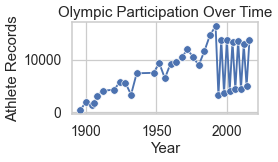

In [48]:
athletes_per_year = olympics.groupby("year").size().reset_index(name="athletes")

sns.lineplot(data=athletes_per_year, x="year", y="athletes", marker="o")

plt.title("Olympic Participation Over Time")
plt.xlabel("Year")
plt.ylabel("Athlete Records")

plt.show()

## 2.2 Participating countries 

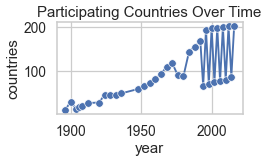

In [49]:
countries_per_year = olympics.groupby("year")["country"].nunique().reset_index(name="countries")

sns.lineplot(data=countries_per_year, x="year", y="countries", marker="o")

plt.title("Participating Countries Over Time")

plt.show()

# 3 Gender Representation

## 3.1 Female participation share

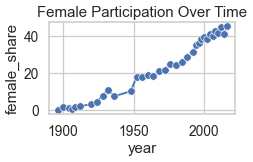

In [50]:
gender = olympics.groupby(["year","gender"]).size().unstack(fill_value=0)

gender["total"] = gender.sum(axis=1)
gender["female_share"] = 100 * gender["F"] / gender["total"]

gender = gender.reset_index()

sns.lineplot(data=gender, x="year", y="female_share", marker="o")

plt.title("Female Participation Over Time")

plt.show()

## 3.2 Male vs female participation

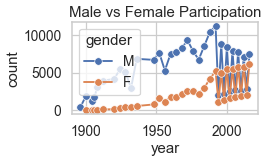

In [51]:
gender_counts = olympics.groupby(["year","gender"]).size().reset_index(name="count")

sns.lineplot(data=gender_counts, x="year", y="count", hue="gender", marker="o")

plt.title("Male vs Female Participation")

plt.show()

In [52]:
gender_time = olympics.groupby(["year", "gender"]).size().reset_index(name="count")

gender_time["gender"] = gender_time["gender"].replace({"M": "Men", "F": "Women"})

all_years = sorted(gender_time["year"].unique())
all_genders = ["Men", "Women"]

full_index = pd.MultiIndex.from_product(
    [all_years, all_genders],
    names=["year", "gender"]
)

gender_time = (
    gender_time
    .set_index(["year", "gender"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

fig_gender = px.bar(
    gender_time,
    x="gender",
    y="count",
    color="gender",
    animation_frame="year",
    range_y=[0, gender_time["count"].max() + 500],
    title="The Path to Parity: Athlete Records Over Time by Gender",
    template="ggplot2",
    color_discrete_map={
        "Men": "#ADD8E6",
        "Women": "#FFB6C1"
    }
)

fig_gender.update_layout(
    xaxis_title="Gender",
    yaxis_title="Number of Athlete Records"
)

fig_gender.show()

In [53]:
gender_share = (
    olympics.groupby(["year", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

gender_share["total"] = gender_share.sum(axis=1)
gender_share["women_share"] = 100 * gender_share["Women"] / gender_share["total"]

print("Women's Share of Athlete Records by Year:")
gender_share[["Women", "Men", "women_share"]].tail(10)

Women's Share of Athlete Records by Year:


gender,Women,Men,women_share
year,,,
1998,1384,2221,38.391123
2000,5431,8390,39.295275
2002,1582,2527,38.500852
2004,5546,7897,41.255672
2006,1757,2625,40.095847
2008,5816,7786,42.758418
2010,1847,2555,41.958201
2012,5815,7105,45.007740
2014,2023,2868,41.361685


#### Basic Statistics: Gender Inequality by Sport

In [54]:
sport_gender = (
    olympics.groupby(["sport", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["women_share"] = 100 * sport_gender["Women"] / sport_gender["total"]

sport_gender.sort_values("women_share").head(10)

gender,Women,Men,total,women_share
sport,,,,
Aeronautics,0,1,1,0.0
Baseball,0,894,894,0.0
Cricket,0,24,24,0.0
Basque Pelota,0,2,2,0.0
Jeu De Paume,0,11,11,0.0
Nordic Combined,0,1344,1344,0.0
Military Ski Patrol,0,24,24,0.0
Lacrosse,0,60,60,0.0
Tug-Of-War,0,170,170,0.0


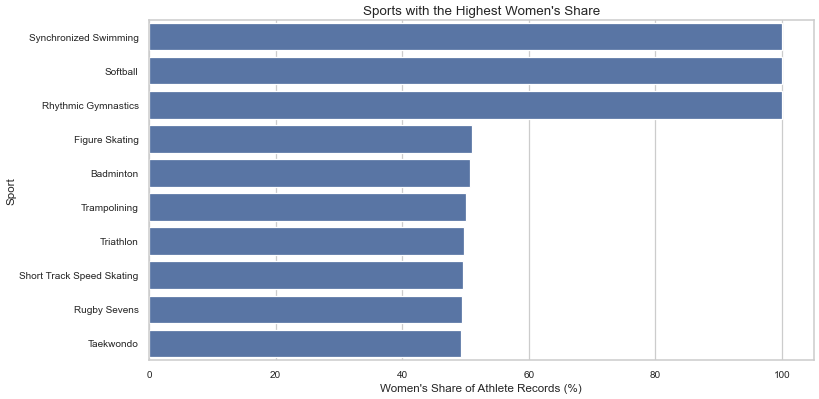

In [55]:
female_balanced = sport_gender.sort_values("women_share", ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=female_balanced, x="women_share", y="sport")
plt.title("Sports with the Highest Women's Share", fontsize=16)
plt.xlabel("Women's Share of Athlete Records (%)", fontsize=14)
plt.ylabel("Sport", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 4 Sports Distribution

## 4.1 Most common sports

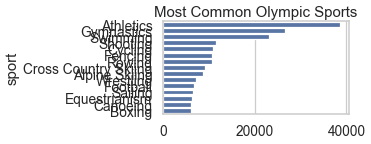

In [56]:
top_sports = olympics["sport"].value_counts().head(15)

sns.barplot(x=top_sports.values, y=top_sports.index)

plt.title("Most Common Olympic Sports")

plt.show()

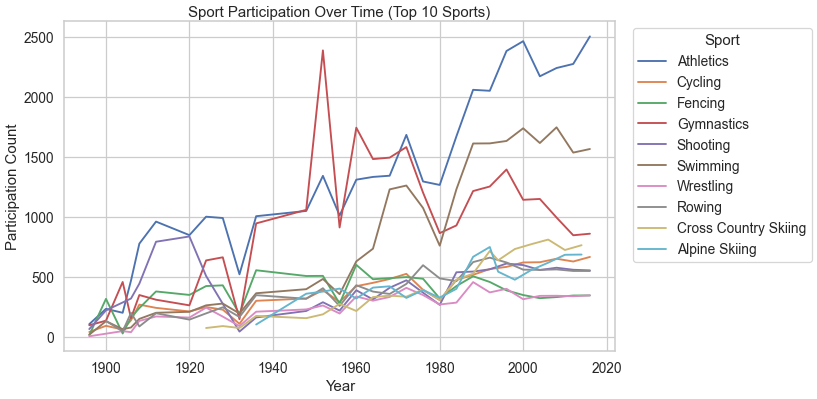

In [57]:
sport_year = (
    olympics.groupby(["year", "sport"])
    .size()
    .reset_index(name="participation_count")
)

# Top sports only
top_sports = (
    sport_year.groupby("sport")["participation_count"]
    .sum()
    .nlargest(10)
    .index
)

sport_year_top = sport_year[sport_year["sport"].isin(top_sports)]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=sport_year_top,
    x="year",
    y="participation_count",
    hue="sport"
)
plt.title("Sport Participation Over Time (Top 10 Sports)")
plt.xlabel("Year")
plt.ylabel("Participation Count")
plt.legend(title="Sport", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [58]:
year_summary = (
    olympics.groupby("year")
    .agg(
        sports=("sport", "nunique"),
        events=("event", "nunique"),
        regions=("country", "nunique")
    )
    .reset_index()
)

year_summary.head()

,year,sports,events,regions
0,1896,9,43,12
1,1900,20,90,31
2,1904,18,95,14
3,1906,13,74,20
4,1908,24,109,22


## 4.2 Female representation by sport

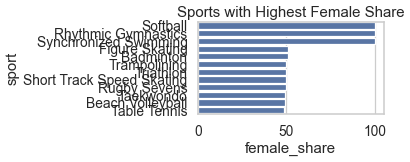

In [59]:
sport_gender = olympics.groupby(["sport","gender"]).size().unstack(fill_value=0)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["female_share"] = 100 * sport_gender["F"] / sport_gender["total"]

sport_gender = sport_gender[sport_gender["total"] > 100]

top_female = sport_gender.sort_values("female_share", ascending=False).head(12)

sns.barplot(x=top_female["female_share"], y=top_female.index)

plt.title("Sports with Highest Female Share")

plt.show()

# 5 Countries & Medals

## 5.1 Countries with largest delegations

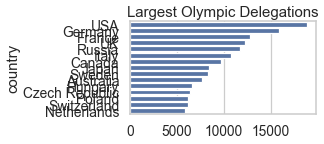

In [60]:
top_countries = olympics["country"].value_counts().head(15)

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Largest Olympic Delegations")

plt.show()

In [61]:
region_year = (
    olympics.groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

print("Countries with the most athlete records:")
olympics["country"].value_counts().head(10)

Countries with the most athlete records:


country
USA          18853
Germany      15883
France       12758
UK           12256
Russia       11692
Italy        10715
Canada        9734
Japan         8444
Sweden        8339
Australia     7724
Name: count, dtype: int64

## 5.2 Countries with most medals

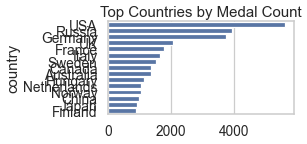

In [62]:
medals = olympics[olympics["medal"].notna()]

medal_counts = medals.groupby("country").size().sort_values(ascending=False)

sns.barplot(x=medal_counts.head(15).values, y=medal_counts.head(15).index)

plt.title("Top Countries by Medal Count")

plt.show()

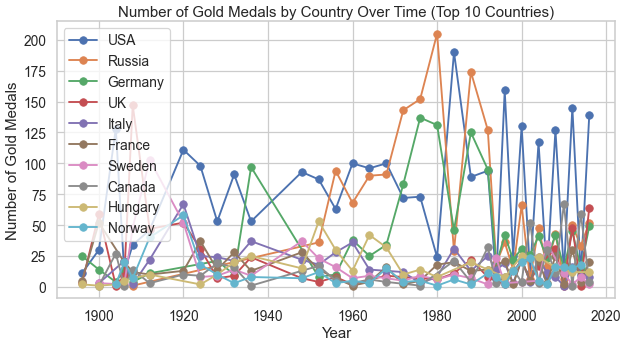

In [63]:
gold_medals = olympics[olympics["medal"] == "Gold"]

gold_year_region = (
    gold_medals
    .groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

top_regions = (
    gold_year_region
    .groupby("country")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

gold_top = gold_year_region[gold_year_region["country"].isin(top_regions)]

plt.figure(figsize=(12, 6))

for country in top_regions:
    country_data = gold_top[gold_top["country"] == country]
    plt.plot(country_data["year"], country_data["count"], marker="o", label=country)

plt.title("Number of Gold Medals by Country Over Time (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Number of Gold Medals")
plt.legend()
plt.show()

In [64]:
fig = px.line(
    gold_top,
    x="year",
    y="count",
    color="country",
    title="Gold Medals by Country Over Time (Top 10 Countries)"
)

fig.show()

## 5.3 Medal inequality

## 5.4 Countries with many participants but no medals

In [65]:
all_countries = set(olympics["country"].dropna().unique())
medal_countries = set(olympics.loc[olympics["medal"].notna(), "country"].dropna().unique())

never_medaled = sorted(all_countries - medal_countries)

never_medaled_df = (
    olympics[olympics["country"].isin(never_medaled)]
    .groupby("country")
    .agg(
        participations=("id", "count"),
        sports=("sport", "nunique")
    )
    .sort_values("participations", ascending=False)
    .reset_index()
)

print(f"Number of countries that never won a medal: {len(never_medaled_df)}")
never_medaled_df.head(10)

Number of countries that never won a medal: 69


,country,participations,sports
0,Angola,267,11
1,El Salvador,218,14
2,Honduras,189,13
3,San Marino,181,14
4,Andorra,169,12
5,Boliva,152,16
6,Bosnia and Herzegovina,134,15
7,Antigua,133,6
8,Nicaragua,129,10
9,Madagascar,119,9


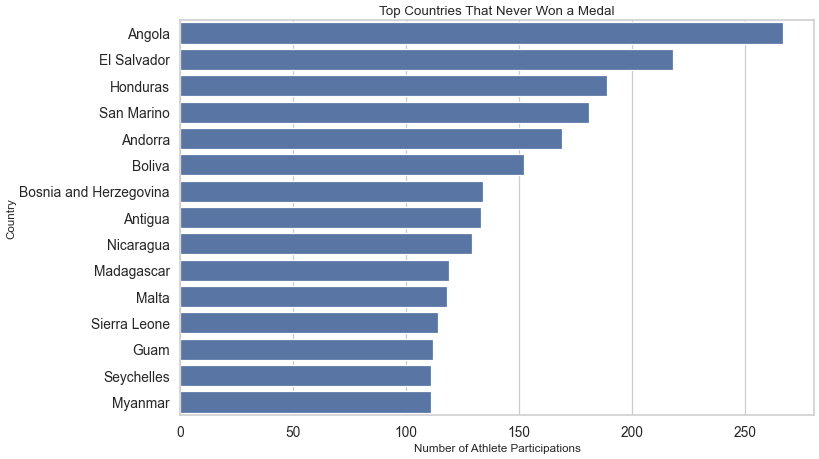

In [66]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=never_medaled_df.head(15),
    x="participations",
    y="country"
)
plt.title("Top Countries That Never Won a Medal", fontsize=16)
plt.xlabel("Number of Athlete Participations", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.tight_layout()
plt.show()

# 6 Economic Inequality

## 6.1 GDP vs medals

In [67]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df.groupby(["country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",              
    hover_name="country",
    title="GDP per Capita vs Medal Count",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population"
    },
    size_max=30 # max bubble size            
)

fig.show()

In [68]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df
    .groupby(["year", "country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",            
    animation_frame="year",
    hover_name="country",
    title="GDP per Capita vs Medal Count Over Time",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population",
        "year": "Year"
    },
    size_max=60                   
)

fig.show()

#### Basic Statistics: Medal Type and Age

## 6.2 Population vs medals

# 7 Athlete Characteristics

## 7.1 Age distribution

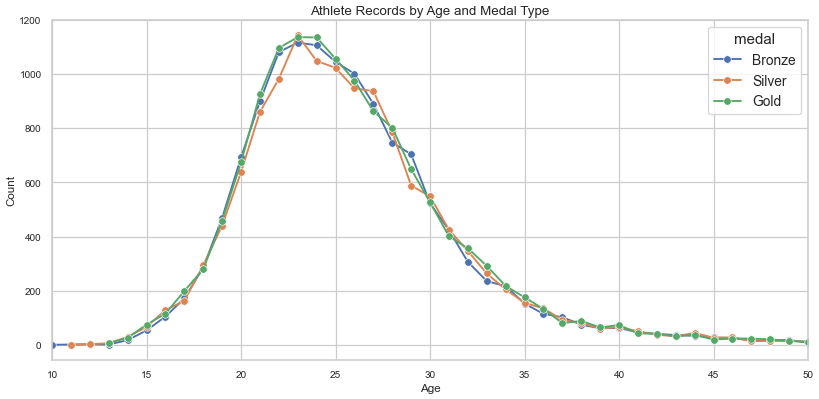

In [69]:
medals_age = olympics.dropna(subset=["age"]).copy()

age_medal = (
    medals_age.groupby(["age", "medal"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=age_medal, x="age", y="count", hue="medal", marker="o")
plt.title("Athlete Records by Age and Medal Type", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xlim(10, 50)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## 7.2 Age and medal performance

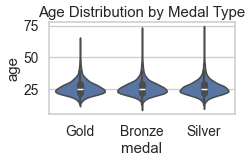

In [70]:
sns.violinplot(data=olympics.dropna(subset=["age","medal"]), x="medal", y="age")

plt.title("Age Distribution by Medal Type")

plt.show()

# 8 Conflicts & Geopolitics

## 8.1 Participation during conflicts

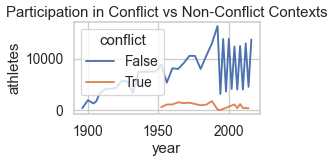

In [71]:
conflict = olympics.copy()
conflict["conflict"] = conflict["conflict_name"].notna()

conflict_counts = conflict.groupby(["year","conflict"]).size().reset_index(name="athletes")

sns.lineplot(data=conflict_counts, x="year", y="athletes", hue="conflict")

plt.title("Participation in Conflict vs Non-Conflict Contexts")

plt.show()